# K-Means + Outlier Buckets (12 Total Groups)

This notebook mirrors the k-means workflow and adds controlled weird-bucket logic:
- fixed total groups = 12
- weird buckets = 1 to 3
- core groups = 12 - weird buckets

Workflow:
1. Build weighted feature matrix
2. Fit k-means for core groups
3. Use distance-to-centroid tail as weird candidates
4. Split weird candidates into 1-3 weird buckets
5. Evaluate + visualize all final groups

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from cluster_utils import (
    attach_labels,
    build_final_labels_with_weird_buckets,
    build_weighted_matrix,
    compute_cluster_compactness,
    evaluate_labels,
    find_repo_root,
    get_feature_groups,
    load_feature_table,
    stack_cluster_outlines,
)

In [8]:
REPO_ROOT = find_repo_root(Path.cwd())
FEATURE_CSV = REPO_ROOT / "hf_space/pipeline/features/silhouette_features.csv"
REAL_IMAGES_DIR = REPO_ROOT / "hf_space/pipeline/real_images"

# Weights
LR_W = 1.0
TB_W = 0.25
SHAPE_W = 1.0
INNER_W = 0.8
INNER_COUNT_W = 0.35

# Base random seed
RANDOM_STATE = 42

FEATURE_CSV, REAL_IMAGES_DIR

(PosixPath('/Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/hf_space/pipeline/features/silhouette_features.csv'),
 PosixPath('/Users/oliviakasmin/Desktop/okasmin-parsons-thesis-2026/hf_space/pipeline/real_images'))

In [9]:
# ---- Main run: fixed 12 total groups with 1-3 weird buckets ----

TOTAL_GROUPS = 12
N_WEIRD_BUCKETS = 2        # choose 1, 2, or 3
WEIRD_PERCENTILE = 90.0    # top tail by distance to centroid
MIN_WEIRD_COUNT = N_WEIRD_BUCKETS
MAX_WEIRD_FRACTION = 0.20  # cap weird candidates to this fraction of rows

# weights
LR_W_RUN = 1.0
TB_W_RUN = 0.20
SHAPE_W_RUN = 1.0
INNER_W_RUN = 1.0

df = load_feature_table(FEATURE_CSV)
groups = get_feature_groups(df)
X, used_cols, imputer, scaler, W = build_weighted_matrix(
    df,
    groups,
    lr_weight=LR_W_RUN,
    tb_weight=TB_W_RUN,
    shape_weight=SHAPE_W_RUN,
    inner_weight=INNER_W_RUN,
)

final_labels, details = build_final_labels_with_weird_buckets(
    X,
    total_groups=TOTAL_GROUPS,
    n_weird_buckets=N_WEIRD_BUCKETS,
    weird_percentile=WEIRD_PERCENTILE,
    min_weird_count=MIN_WEIRD_COUNT,
    max_weird_fraction=MAX_WEIRD_FRACTION,
)

df_labeled = attach_labels(df, final_labels)
metrics = evaluate_labels(X, final_labels)
compactness = compute_cluster_compactness(X, final_labels)

print("Run summary:")
print({
    "total_groups": TOTAL_GROUPS,
    "n_core": details["n_core"],
    "n_weird_buckets": details["n_weird_buckets"],
    "weird_percentile": details["weird_percentile"],
    "weird_count": details["weird_count"],
    "distance_threshold": details["distance_threshold"],
})
print("Metrics:")
print(metrics)

display(compactness)
print(df_labeled["cluster"].value_counts().sort_index())

Run summary:
{'total_groups': 12, 'n_core': 10, 'n_weird_buckets': 2, 'weird_percentile': 90.0, 'weird_count': 389, 'distance_threshold': 12.423283631126216}
Metrics:
{'n_rows': 3888, 'n_features': 297, 'n_clusters': 12, 'silhouette': 0.12616599148011026, 'calinski_harabasz': 434.7726514953246, 'davies_bouldin': 2.6413927749465933}


,cluster,size,mean_dist_to_centroid,median_dist_to_centroid,p90_dist_to_centroid
2,2,616,5.143655,4.874658,7.540430
4,4,491,6.061973,5.428221,9.524626
1,1,665,6.378601,5.820267,9.486596
7,7,510,7.084746,6.796176,10.359530
6,6,342,7.297467,6.748512,10.684621
0,0,427,7.881529,7.661541,10.716894
3,3,244,8.351841,8.077995,11.191763
9,9,65,9.192044,9.246671,11.852810
5,5,27,9.623206,9.876146,11.555087
8,8,112,10.096823,10.280965,11.888014


cluster
0     427
1     665
2     616
3     244
4     491
5      27
6     342
7     510
8     112
9      65
10    220
11    169
Name: count, dtype: int64


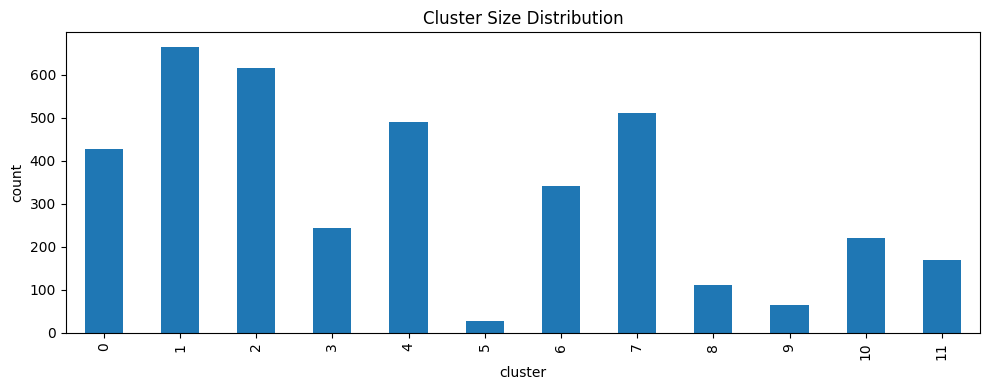

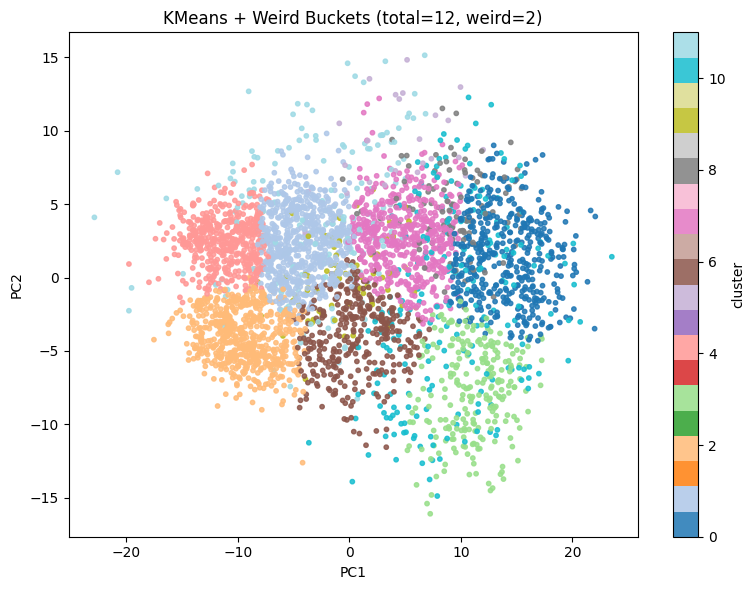

In [10]:
# ---- Visual diagnostics ----

def plot_cluster_sizes(df_labeled: pd.DataFrame):
    counts = df_labeled["cluster"].value_counts().sort_index()
    plt.figure(figsize=(10, 4))
    counts.plot(kind="bar")
    plt.title("Cluster Size Distribution")
    plt.xlabel("cluster")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


def plot_pca_projection(X: np.ndarray, labels: np.ndarray, title: str):
    pca = PCA(n_components=2, random_state=42)
    points = pca.fit_transform(X)
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(points[:, 0], points[:, 1], c=labels, s=10, cmap="tab20", alpha=0.85)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(sc, label="cluster")
    plt.tight_layout()
    plt.show()


plot_cluster_sizes(df_labeled)
plot_pca_projection(X, final_labels, title=f"KMeans + Weird Buckets (total={TOTAL_GROUPS}, weird={N_WEIRD_BUCKETS})")

Weird labels: [10, 11]
Core labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
cluster=10 (weird), n=220


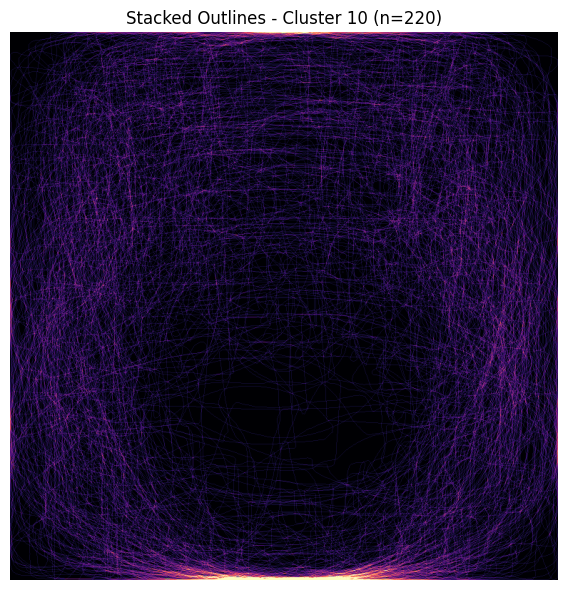

['185900', '187863', '188993', '191780', '194471', '194591', '194906', '195127', '196568', '197532', '197570', '198416', '199051', '199338', '199372', '199601', '199730', '200868', '200917', '201359', '201394', '201730', '201732', '201738', '202191', '202192', '203282', '203304', '204026', '204047']
cluster=11 (weird), n=169


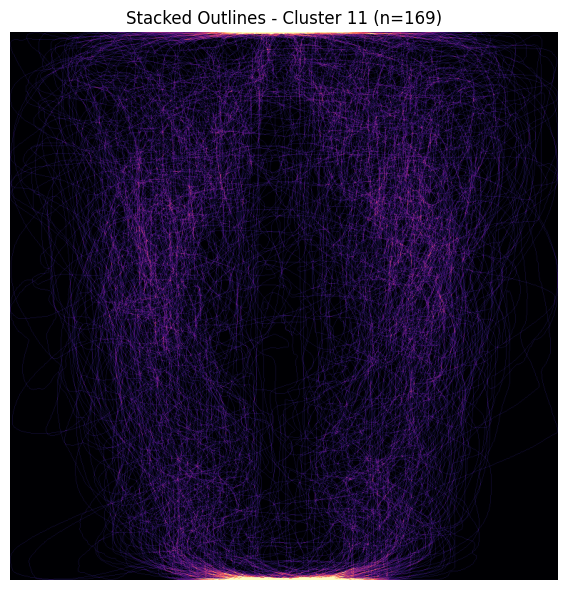

['185901', '185914', '187701', '187805', '187857', '187860', '188645', '188900', '188974', '191142', '191206', '191218', '191375', '191731', '192014', '192810', '192854', '194243', '194262', '194279', '194307', '194395', '194439', '194967', '195013', '195041', '195272', '195277', '195302', '195766']
cluster=0 (core), n=427


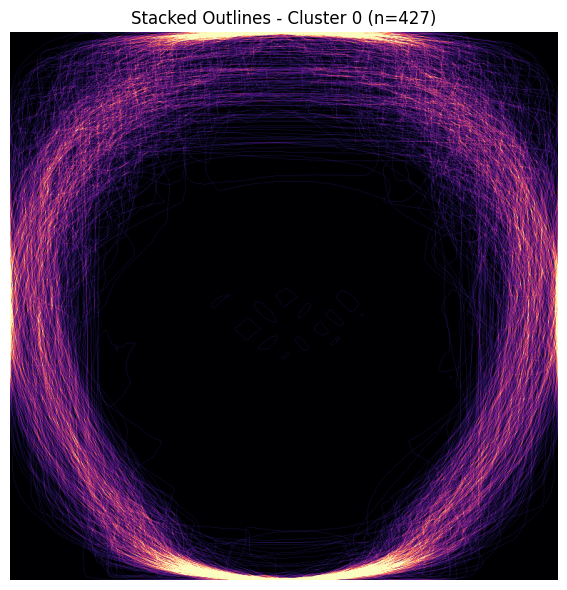

['188556', '195208', '195209', '198433', '198780', '198781', '199343', '199470', '199740', '200839', '200840', '200875', '200876', '201290', '202967', '203266', '204392', '206328', '207815', '208009', '208121', '208122', '208248', '208403', '208554', '307615', '308348', '308420', '308492', '308531']
cluster=1 (core), n=665


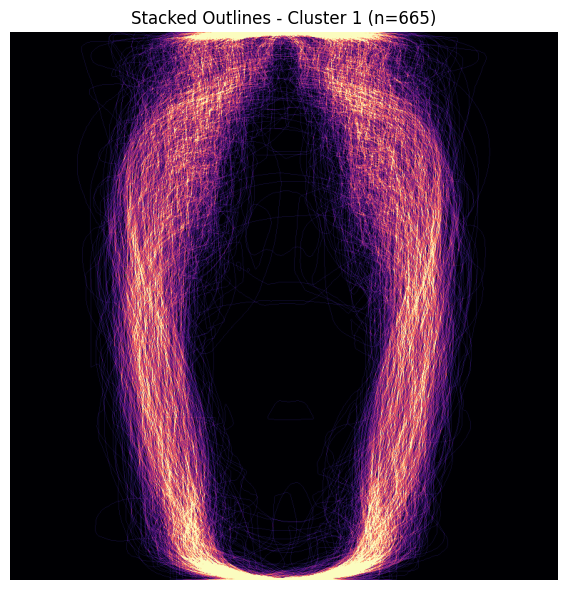

['187702', '187749', '187750', '187794', '188541', '188563', '188633', '188753', '188972', '190547', '190600', '190649', '190657', '191344', '191593', '191733', '191779', '193084', '194261', '194298', '194303', '194380', '194383', '194390', '194392', '194432', '194472', '194479', '194582', '194586']
cluster=2 (core), n=616


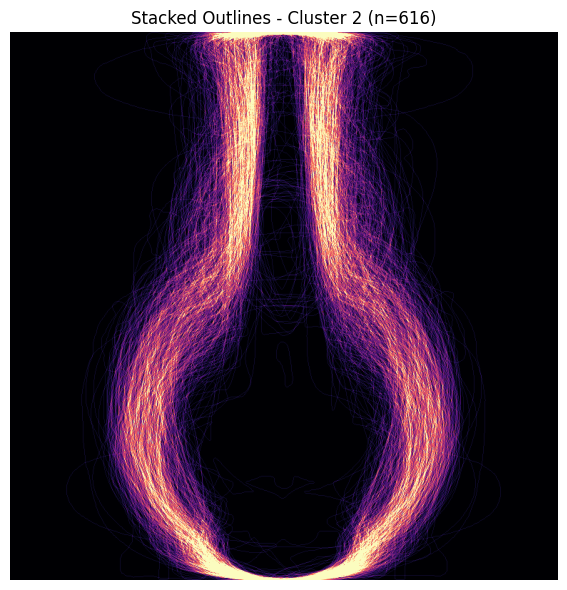

['187746', '187748', '190732', '191213', '192800', '192802', '194228', '194232', '194239', '194288', '194588', '195500', '195501', '196359', '196360', '196361', '196567', '197232', '197233', '197515', '197829', '198322', '198707', '199273', '199334', '199337', '199348', '199461', '199466', '199559']
cluster=3 (core), n=244


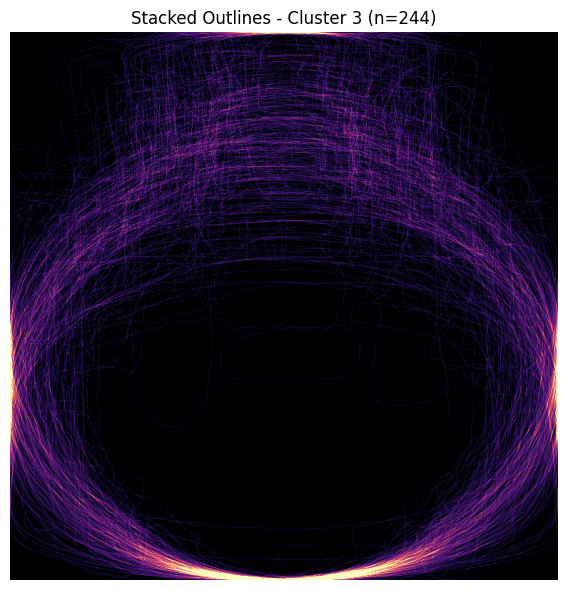

['192949', '194590', '199021', '200734', '200841', '201250', '201881', '202205', '207152', '207477', '208439', '208459', '307619', '307620', '307622', '307865', '307866', '307868', '308291', '308292', '308293', '308294', '308296', '308297', '308298', '308300', '308303', '308350', '308355', '308359']
cluster=4 (core), n=491


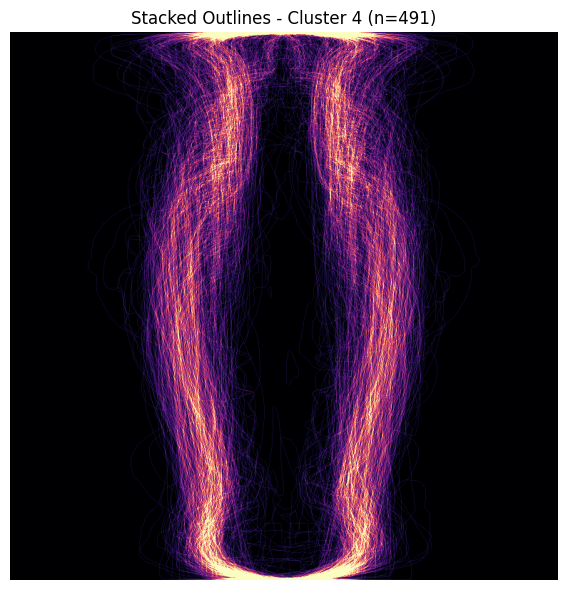

['187660', '187801', '187856', '187858', '187859', '188536', '188537', '188538', '188539', '188777', '190474', '190797', '191600', '191636', '191778', '192801', '192811', '192830', '192831', '192844', '193449', '194229', '194230', '194231', '194233', '194234', '194235', '194236', '194238', '194246']
cluster=5 (core), n=27


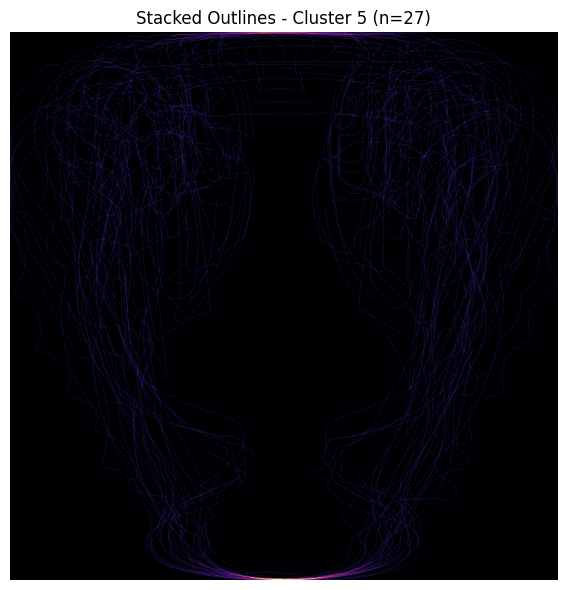

['186684', '188908', '194301', '198669', '198939', '199733', '199752', '204511', '204512', '204513', '207399', '44721', '449072', '452610', '45849', '460132', '460133', '460147', '460173', '460175', '460180', '460715', '460716', '49905', '50960', '771041', '857949']
cluster=6 (core), n=342


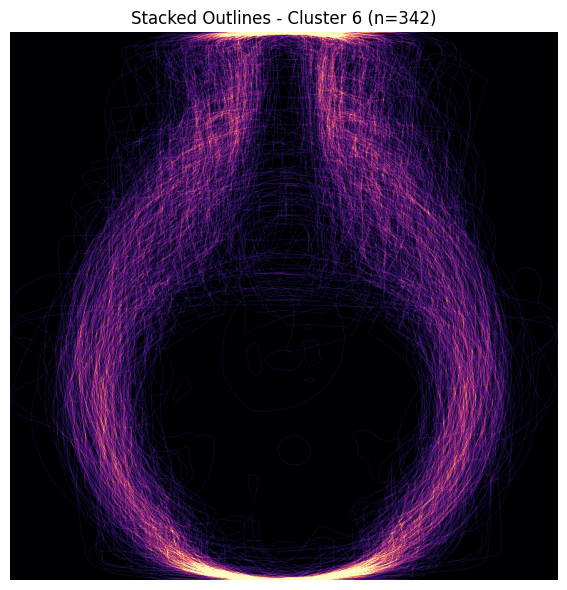

['188765', '190647', '194291', '194304', '194475', '194583', '195217', '197612', '197993', '198963', '199110', '200823', '200921', '200944', '202193', '202243', '202581', '203299', '204046', '204062', '207775', '207776', '207983', '208389', '208556', '208806', '210743', '239563', '307873', '308301']
cluster=7 (core), n=510


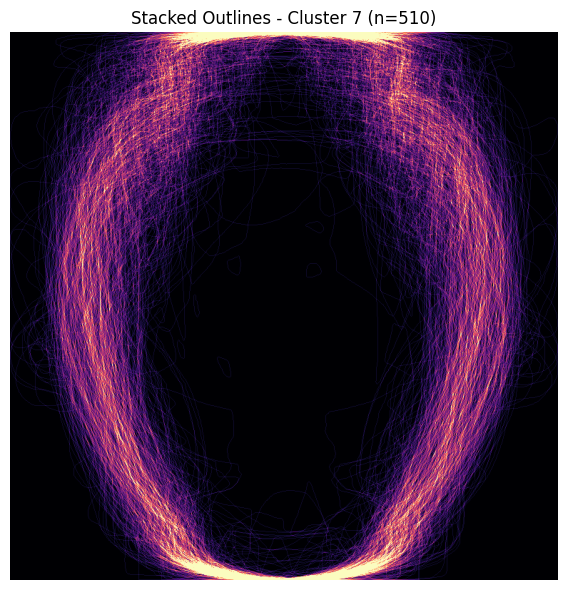

['185902', '187733', '187791', '187828', '187829', '187854', '187871', '188533', '188534', '188535', '188976', '188998', '190648', '191583', '192034', '192308', '192803', '193020', '193109', '194287', '194391', '194433', '194624', '194963', '195499', '195741', '195742', '196544', '196601', '197224']
cluster=8 (core), n=112


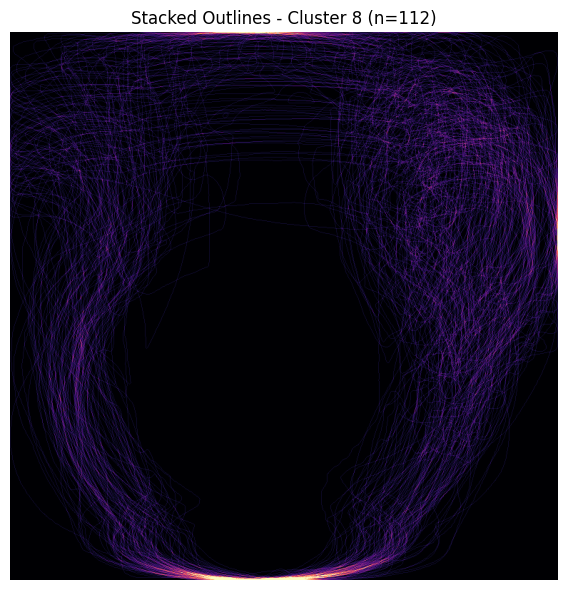

['188994', '193062', '193063', '193064', '193077', '193093', '193355', '194292', '194488', '194632', '194636', '194637', '194639', '194644', '195307', '197552', '197572', '197614', '197616', '198409', '198426', '198432', '198575', '199026', '199134', '199320', '199415', '199568', '199570', '199765']
cluster=9 (core), n=65


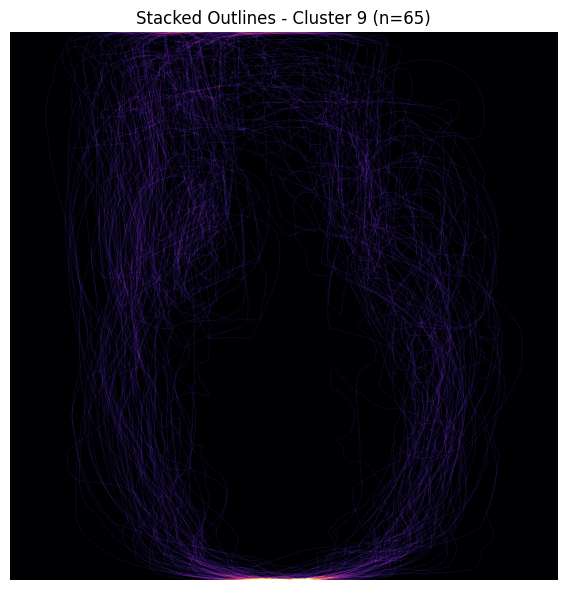

['186687', '195780', '197605', '199195', '199332', '199417', '203298', '204098', '205973', '206517', '207777', '208409', '208542', '307472', '308381', '308439', '308526', '308542', '308544', '308550', '309325', '309326', '309337', '309339', '309344', '309357', '309366', '309370', '309372', '309373']


In [11]:
# ---- Automatic overlay loops (weird buckets first) ----

n_core = details["n_core"]
weird_labels = list(range(n_core, n_core + N_WEIRD_BUCKETS))
core_labels = [c for c in sorted(df_labeled["cluster"].unique().tolist()) if c not in weird_labels]

print("Weird labels:", weird_labels)
print("Core labels:", core_labels)

ordered_labels = weird_labels + core_labels
for cluster_id in ordered_labels:
    print("=" * 80)
    n_cluster = len(df_labeled[df_labeled["cluster"] == cluster_id])
    kind = "weird" if cluster_id in weird_labels else "core"
    print(f"cluster={cluster_id} ({kind}), n={n_cluster}")

    _ = stack_cluster_outlines(
        df_labeled,
        cluster_id=cluster_id,
        real_images_dir=REAL_IMAGES_DIR,
        max_images=None,
        alpha_per_image=0.08,
    )

    sample_ids = (
        df_labeled.loc[df_labeled["cluster"] == cluster_id, "object_id"]
        .astype(str)
        .head(30)
        .tolist()
    )
    print(sample_ids)

In [12]:
# ---- Sweep helper for weird bucket variants (1..3) while keeping 12 total ----

sweep_rows = []
for weird_n in [1, 2, 3]:
    labels_s, details_s = build_final_labels_with_weird_buckets(
        X,
        total_groups=12,
        n_weird_buckets=weird_n,
        weird_percentile=WEIRD_PERCENTILE,
        min_weird_count=weird_n,
        max_weird_fraction=MAX_WEIRD_FRACTION,
    )
    metrics_s = evaluate_labels(X, labels_s)
    compact_s = compute_cluster_compactness(X, labels_s)
    top8_mean_dist = float(compact_s.head(8)["mean_dist_to_centroid"].mean()) if len(compact_s) >= 8 else np.nan

    sweep_rows.append(
        {
            "weird_buckets": weird_n,
            "core_clusters": 12 - weird_n,
            "weird_count": details_s["weird_count"],
            "silhouette": metrics_s["silhouette"],
            "calinski_harabasz": metrics_s["calinski_harabasz"],
            "davies_bouldin": metrics_s["davies_bouldin"],
            "top8_mean_dist": top8_mean_dist,
        }
    )

pd.DataFrame(sweep_rows).sort_values(by=["silhouette", "davies_bouldin"], ascending=[False, True])

,weird_buckets,core_clusters,weird_count,silhouette,calinski_harabasz,davies_bouldin,top8_mean_dist
2,3,9,389,0.127603,446.147521,2.614922,7.306743
1,2,10,389,0.126166,434.772651,2.641393,7.173982
0,1,11,389,0.112355,383.040948,2.592962,7.322893
